In [76]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import plotly.graph_objects as go
from shapely import wkt

# df['geometry'] = df['geometry'].apply(wkt.loads)

In [77]:
os.getcwd()
# sys.path.append(project_root)
# # Import the class
# from mimi_ml.classification_class import Classification
# from mimi_ml.general_functions import calculate_actual_predicted
# from mimi_ml.visualisations import visualise_actual_predicted_map

print("Loaded successfully!")


Loaded successfully!


In [78]:


def visualise_features_map(
    geo_df,
    col,
    mn: str,
    comparison: bool = True,
    color='Blues',
    adminsfontsize=14,
    iso3=None,
    threshold=None,
    title=None,
    save: bool = False,
    path: str = None
):
    """
    Creates a choropleth map directly from a geodataframe.

    Parameters
    ----------
    geo_df : GeoDataFrame
        Must already contain geometry, 'Name', and the column to plot
    col : str
        Column to visualise
    mn : str
        Micronutrient name (e.g. 'zn_ai')
    comparison : bool
        If True, sets fixed scale (0–1)
    color : str
        Matplotlib colormap
    adminsfontsize : int
        Font size for admin labels
    """
    plt.close('all')
    # keep only required columns
    to_vis = geo_df[[col, 'geometry', 'Name']].copy()
    to_vis = gpd.GeoDataFrame(to_vis, geometry='geometry')

    # ✅ range logic
    if comparison:
        vmin, vmax = 0, 1
    else:
        vmin, vmax = to_vis[col].min(), to_vis[col].max()

    # ✅ title logic
    dict_title = {
        'actual': 'Actual percentage',
        'actual_rank': 'Actual ranking',
        'predicted': 'Predicted percentage',
        'predicted_rank': 'Predicted ranking'
    }

    title_col = dict_title.get(col, col)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.set_axis_off()

    if title is None:
        ax.set_title(
            f'{title_col} of risk of inadequate {mn} intake',
            loc='center',
            pad=10,
            fontdict={'fontsize': 17, 'fontname': 'arial', 'fontweight': 'bold'}
        )
    else:
        ax.set_title(
            f'{title_col} {title}',
            loc='center',
            pad=10,
            fontdict={'fontsize': 17, 'fontname': 'Arial', 'fontweight': 'bold'}
        )

   
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
   
    to_vis.plot(
        column=col,
        cmap=color,
        norm=norm,
        ax=ax,
        linewidth=0.8,
        edgecolor='grey'
    )

    sm = plt.cm.ScalarMappable(cmap=color, norm=norm)
    sm._A = []

    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.3, pad=0.05)
    cbar.ax.tick_params(labelsize=11)
    cbar.outline.set_visible(False)

    # ✅ safer centroid handling
    centroids = to_vis.geometry.centroid

    for x, y, name in zip(centroids.x, centroids.y, to_vis['Name']):
        ax.text(x, y, name, fontsize=adminsfontsize, fontname='arial')

    # ✅ save option
    if save and path is not None:
        plt.savefig(
            f"{path}{iso3}_{mn}_{col}_{threshold}_map.pdf",
            bbox_inches="tight"
        )

    plt.tight_layout()
    plt.show()


In [115]:

def visualise_features_map_plotly(geo_df, col, mn, comparison=True, color="Blues"):

    geo_df = geo_df.reset_index(drop=True)

    geojson = json.loads(geo_df.to_json())

    # ✅ force index-based matching
    for i, feature in enumerate(geojson["features"]):
        feature["id"] = str(i)

    if comparison:
        range_color = (0, 1)
    else:
        range_color = (geo_df[col].min(), geo_df[col].max())

    fig = px.choropleth(
        geo_df,
        geojson=geojson,
        locations=geo_df.index.astype(str),
        color=col,
        color_continuous_scale=color,
        range_color=range_color
    )

    fig.update_geos(fitbounds="locations", visible=False)

    return fig


In [80]:
hh_info19 = pd.read_csv(path+"sri_lanka19_roster_geo.csv").rename(columns = {"Unnamed: 0":'hhid'})
hh_info19

,hhid,district,adm1Geometry,adm1Code,adm1Name,adm2Code,adm2Name,adm2Geometry,adm2Name_y,predicted,actual,weight
0,11100111,Colombo,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,1,298.042313
1,11100141,Colombo,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1,1,298.042313
2,11100191,Colombo,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,0,298.042313
3,11100341,Colombo,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1,1,285.601283
4,11100361,Colombo,"POLYGON ((80.1789 6.8028, 80.1768 6.8121, 80.1...",2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,0,285.601283
...,...,...,...,...,...,...,...,...,...,...,...,...
2898,19208221,Kegalle,"POLYGON ((80.4211 7.3542, 80.4144 7.3567, 80.4...",2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,1,0,313.297421
2899,19208231,Kegalle,"POLYGON ((80.4211 7.3542, 80.4144 7.3567, 80.4...",2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,0,313.297421
2900,19208461,Kegalle,"POLYGON ((80.4211 7.3542, 80.4144 7.3567, 80.4...",2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,0,343.361028
2901,19208531,Kegalle,"POLYGON ((80.4211 7.3542, 80.4144 7.3567, 80.4...",2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,1,259.314922


In [81]:
path = '../../data/raw/features/'
features19 = pd.read_csv(path+'features19.csv', index_col=0)
features19 = features19.merge(hh_info19, on = 'hhid')

In [82]:
hh_info24 = pd.read_csv(path+"sri_lanka24_roster_geo.csv").rename(columns={"@_id":"hhid"})
hh_info24

,Unnamed: 0,hhid,adm2Name,adm2Code,adm2Geometry,adm1Name,adm1Code,adm1Geometry
0,0,64979777,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
1,1,64864373,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
2,2,65572640,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
3,3,65031840,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
4,4,64977799,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
...,...,...,...,...,...,...,...,...
15095,15095,66449824,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15096,15096,66449825,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15097,15097,66449828,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15098,15098,66449829,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."


In [83]:
#features24 = pd.read_csv(path + 'features24')
features24 = pd.read_csv(path+'features24.csv', index_col=0)
features24 = features24.merge(hh_info24, on = 'hhid')
features24

,hhid,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,...,r3q,rfh_avg,food_exp_share,Unnamed: 0,adm2Name,adm2Code,adm2Geometry,adm1Name,adm1Code,adm1Geometry
0,64979777,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,108.97085,30.56250,0.589178,0,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
1,64864373,1.0,1.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,...,108.97085,30.56250,0.642810,1,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
2,65572640,0.0,0.0,0.0,4.0,1.0,1.0,1.0,1.0,1.0,...,108.97085,30.56250,0.375487,2,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
3,65031840,0.0,0.0,0.0,4.0,1.0,1.0,0.0,0.0,1.0,...,108.97085,30.56250,0.543685,3,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
4,64977799,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,...,108.97085,30.56250,0.522711,4,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15095,66449824,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,94.71260,31.70435,0.493480,15095,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15096,66449825,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,94.71260,31.70435,0.556831,15096,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15097,66449828,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,94.71260,31.70435,0.704062,15097,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15098,66449829,0.0,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,...,94.71260,31.70435,0.705674,15098,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."


In [84]:
hh_info24

,Unnamed: 0,hhid,adm2Name,adm2Code,adm2Geometry,adm1Name,adm1Code,adm1Geometry
0,0,64979777,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
1,1,64864373,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
2,2,65572640,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
3,3,65031840,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
4,4,64977799,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
...,...,...,...,...,...,...,...,...
15095,15095,66449824,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15096,15096,66449825,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15097,15097,66449828,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."
15098,15098,66449829,Vavuniya,25843.0,POLYGON ((8970569.846085157 1020258.4668322554...,Northern,2740.0,"MULTIPOLYGON (((79.9083 9.7455, 79.9104 9.7472..."


In [85]:

features19["year"] = "2019"
features24["year"] = "2024"

features_all = pd.concat([features19, features24], ignore_index=True)
features_all

,hhid,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,...,adm1Name,adm2Code,adm2Name,adm2Geometry,adm2Name_y,predicted,actual,weight,year,Unnamed: 0
0,11100111,1.0,1.0,1.0,4.0,1.0,1.0,0.0,1.0,1.0,...,Western,25851.0,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0.0,1.0,298.042313,2019,NaN
1,11100141,1.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,...,Western,25851.0,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1.0,1.0,298.042313,2019,NaN
2,11100191,0.0,0.0,0.0,5.0,1.0,1.0,0.0,1.0,1.0,...,Western,25851.0,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0.0,0.0,298.042313,2019,NaN
3,11100491,1.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,...,Western,25851.0,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1.0,0.0,271.985202,2019,NaN
4,11104591,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,...,Western,25851.0,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0.0,0.0,361.692033,2019,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17998,66449824,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,Northern,25843.0,Vavuniya,POLYGON ((8970569.846085157 1020258.4668322554...,NaN,NaN,NaN,NaN,2024,15095.0
17999,66449825,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,Northern,25843.0,Vavuniya,POLYGON ((8970569.846085157 1020258.4668322554...,NaN,NaN,NaN,NaN,2024,15096.0
18000,66449828,0.0,0.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,...,Northern,25843.0,Vavuniya,POLYGON ((8970569.846085157 1020258.4668322554...,NaN,NaN,NaN,NaN,2024,15097.0
18001,66449829,0.0,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,...,Northern,25843.0,Vavuniya,POLYGON ((8970569.846085157 1020258.4668322554...,NaN,NaN,NaN,NaN,2024,15098.0


In [86]:
features_all.columns

Index(['hhid', 'asset1', 'asset7', 'asset8', 'education2', 'food group1',
       'food group2', 'food group3', 'food group4', 'food group5',
       'food group6', 'food group7', 'food group8', 'food group9', 'housing1',
       'housing2', 'housing4', 'labour1', 'labour2', 'labour4', 'r3q',
       'rfh_avg', 'food_exp_share', 'district', 'adm1Geometry', 'adm1Code',
       'adm1Name', 'adm2Code', 'adm2Name', 'adm2Geometry', 'adm2Name_y',
       'predicted', 'actual', 'weight', 'year', 'Unnamed: 0'],
      dtype='object')

In [87]:


def weighted_avg_column(df, columns, weight=None, group=None):
    if isinstance(columns, str):
        columns = [columns]

    def wmean(x, w):
        mask = x.notna() & w.notna()
        if mask.sum() == 0 or np.sum(w[mask]) == 0:
            return np.nan
        return np.sum(x[mask] * w[mask]) / np.sum(w[mask])

    # If no weight provided → use 1s
    if weight is None:
        weights = pd.Series(1, index=df.index)
    else:
        weights = df[weight]

    if group is not None:
        result = (
            df
            .groupby(group)
            .apply(lambda g: pd.Series({
                col: wmean(g[col], weights.loc[g.index]) for col in columns
            }))
        )
    else:
        result = pd.DataFrame([{
                    col: wmean(df[col], weights) for col in columns
                }], index=["national"])

    return result




In [88]:
feature_averages = ["food group1", "food group2", "food group3","food group4", "food group5", "food group6",
     "food group7", "food group8", "food group9", "food_exp_share",'asset1', 'asset7', 'asset8', 'education2']

features19


,hhid,asset1,asset7,asset8,education2,food group1,food group2,food group3,food group4,food group5,...,adm1Code,adm1Name,adm2Code,adm2Name,adm2Geometry,adm2Name_y,predicted,actual,weight,year
0,11100111,1.0,1.0,1.0,4.0,1.0,1.0,0.0,1.0,1.0,...,2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,1,298.042313,2019
1,11100141,1.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,...,2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1,1,298.042313,2019
2,11100191,0.0,0.0,0.0,5.0,1.0,1.0,0.0,1.0,1.0,...,2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,0,298.042313,2019
3,11100491,1.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,...,2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,1,0,271.985202,2019
4,11104591,1.0,1.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,...,2744,Western,25851,Colombo,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",Colombo,0,0,361.692033,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2898,19208461,1.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,1.0,...,2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,0,343.361028,2019
2899,192042101,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,...,2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,0,340.774504,2019
2900,19204021,0.0,0.0,0.0,4.0,1.0,1.0,0.0,1.0,0.0,...,2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,1,0,349.365458,2019
2901,19208531,0.0,0.0,0.0,2.0,1.0,1.0,0.0,1.0,1.0,...,2741,Sabaragamuwa,25844,Kegalle,"POLYGON ((80.495 6.8316, 80.4968 6.8346, 80.50...",Kegalle,0,1,259.314922,2019


In [89]:


df19 = weighted_avg_column(
    features19,
     feature_averages ,
     group=['adm2Name', 'adm2Code', 'adm2Geometry'], weight = 'weight',
).reset_index().rename(columns={'adm2Geometry':'geometry', "adm2Name":'Name'})

df19

C:\Users\gabriel.battcock\AppData\Local\Temp\ipykernel_9048\1666483342.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Name,adm2Code,geometry,food group1,food group2,food group3,food group4,food group5,food group6,food group7,food group8,food group9,food_exp_share,asset1,asset7,asset8,education2
0,Ampara,25832,"POLYGON ((81.2403 7.7385, 81.2378 7.7348, 81.2...",1.000000,0.990856,0.052862,0.990960,0.978771,0.607372,0.902888,0.981874,1.000000,0.585186,0.492536,0.568391,0.060463,3.605078
1,Anuradhapura,25835,"POLYGON ((80.9414 8.3419, 80.9363 8.3492, 80.9...",0.976423,0.976423,0.060586,0.943518,0.976423,0.643225,0.942365,0.985840,0.976423,0.392066,0.660503,0.698449,0.112355,3.794214
2,Badulla,25849,"POLYGON ((81.271 7.2782, 81.2679 7.2846, 81.27...",0.991610,0.987030,0.101213,0.905520,0.987030,0.497291,0.957639,0.988455,0.978500,0.507460,0.397700,0.145379,0.035556,3.073034
3,Batticaloa,25833,"POLYGON ((81.357 8.2578, 81.3549 8.2601, 81.35...",0.973356,0.973356,0.077117,0.931026,0.973356,0.486214,0.840176,0.939506,0.961833,0.600451,0.383657,0.354254,0.017791,3.097459
4,Colombo,25851,"POLYGON ((79.9011 6.7153, 79.9026 6.7162, 79.9...",0.979743,0.985441,0.217090,0.967440,0.963851,0.806330,0.937902,0.997448,0.949083,0.323769,0.834676,0.312445,0.284239,4.126598
5,Galle,25846,"POLYGON ((79.9908 6.4423, 79.9884 6.4415, 79.9...",0.978768,0.976357,0.094736,0.952309,0.941569,0.680188,0.949083,0.995046,0.972155,0.455890,0.664487,0.417049,0.062519,3.511736
6,Gampaha,25852,"POLYGON ((80.1243 7.3302, 80.1199 7.3262, 80.1...",0.957156,0.961977,0.151244,0.947984,0.939751,0.723998,0.894215,0.986205,0.946878,0.373493,0.777286,0.476133,0.179294,4.045136
7,Hambantota,25847,"POLYGON ((80.6798 6.1011, 80.6814 6.0978, 80.6...",0.943192,0.958504,0.050402,0.921816,0.943192,0.581602,0.791520,0.936552,0.879080,0.455101,0.615730,0.434808,0.088810,3.165365
8,Jaffna,25839,"MULTIPOLYGON (((79.66 9.5556, 79.6536 9.5509, ...",0.953153,0.953153,0.235859,0.844846,0.935037,0.383192,0.913442,0.971224,0.943109,0.535795,0.434100,0.506968,0.070662,3.855164
9,Kalutara,25853,"POLYGON ((80.1494 6.8241, 80.1484 6.8239, 80.1...",0.974563,0.964766,0.108434,0.964339,0.951522,0.609795,0.883935,0.989787,0.958584,0.442064,0.649235,0.424504,0.106443,3.902962


In [90]:
df24 = weighted_avg_column(
    features24,
     feature_averages,
     group=['adm2Name', 'adm2Code', 'adm2Geometry']
).reset_index().rename(columns={'adm2Geometry':'geometry', "adm2Name":'Name'})


C:\Users\gabriel.battcock\AppData\Local\Temp\ipykernel_9048\1666483342.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [109]:
df24 = gpd.GeoDataFrame(df24, geometry="geometry")
df19 = gpd.GeoDataFrame(df19, geometry="geometry")

df24 = df24.set_crs("EPSG:4326")
df19 = df19.set_crs("EPSG:4326")




C:\Users\gabriel.battcock\AppData\Local\Temp\ipykernel_9048\906027662.py:91: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = to_vis.geometry.centroid


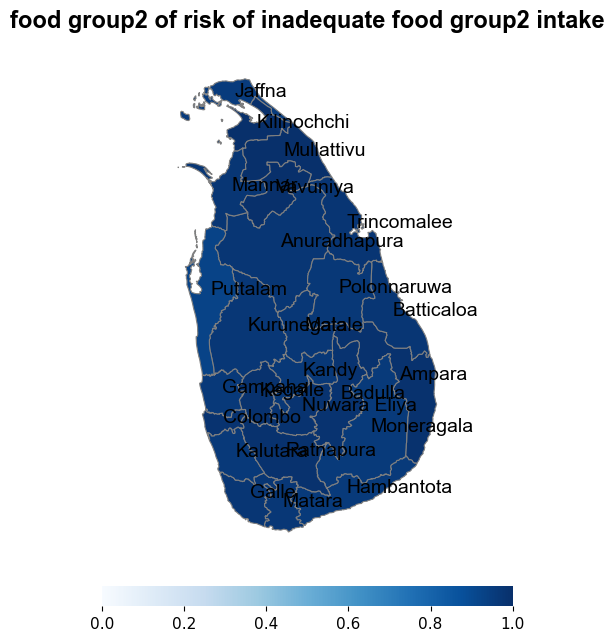

In [110]:
visualise_features_map(df19,'food group2', 'food group2')

In [23]:
for item in feature_averages:
    print(1)
    # visualise_features_map(df24,item, item)

1
1
1
1
1
1
1
1
1
1


In [108]:
df24.total_bounds

array([ 99.04080546,   2.93074113, 100.05136937,   4.90689489])

In [116]:
import dash
from dash import dcc, html, Output, Input, State
import plotly.express as px
import plotly.graph_objects as go

# Assume these exist
# df19, df24, features_all
# and your function:
# visualise_features_map(df, var, label)

app = dash.Dash(__name__)

# -------------------------
# LAYOUT
# -------------------------
app.layout = html.Div([

    html.Div([
        dcc.Dropdown(
            options=[
                {"label": "Food group 2", "value": "food group2"},
                {"label": "Food group 3", "value": "food group3"},
            ],
            value="food group2",
            id="variable-select",
        ),
        html.Button("Compare Mode", id="compare-btn", n_clicks=0),
    ]),

    dcc.Store(id="view-state", data={"compare": True}),

   

    

    html.H3("Distributions"),
    html.Div(id="hist-container"),

    html.Hr(),

    html.H3("Maps"),
    html.Div(id="maps-container")

])

# -------------------------
# TOGGLE COMPARE MODE
# -------------------------
@app.callback(
    Output("view-state", "data"),
    Input("compare-btn", "n_clicks"),
    State("view-state", "data"),
)
def toggle_compare(n_clicks, state):
    state["compare"] = (n_clicks % 2 == 1)
    return state


@app.callback(
    Output("hist-container", "children"),
    Input("variable-select", "value"),
)
def update_binary_plots(selected_var):
    plt.close('all')

    df_2019 = features_all[features_all["year"] == "2019"]
    df_2024 = features_all[features_all["year"] == "2024"]

    # Compute proportions (mean of 0/1 = prevalence)
    p19 = df_2019[selected_var].mean()
    p24 = df_2024[selected_var].mean()


    fig = go.Figure(data=[
        go.Bar(name="2019", x=[selected_var], y=[p19]),
        go.Bar(name="2024", x=[selected_var], y=[p24])
    ])

    fig.update_layout(
        barmode="group",
        title=f"Prevalence of {selected_var}",
        yaxis_title="Proportion",
        yaxis=dict(range=[0, 1])
    )

    return dcc.Graph(figure=fig)



# -------------------------
# UPDATE MAPS
# -------------------------
@app.callback(
    Output("maps-container", "children"),
    Input("variable-select", "value"),
    Input("view-state", "data"),
)
def update_maps(selected_var, state):
    
    fig_2024 = visualise_features_map_plotly(df24, selected_var, selected_var)

    if state["compare"]:
        fig_2019 = visualise_features_map_plotly(df19, selected_var, selected_var)

        return html.Div([
            dcc.Graph(figure=fig_2019),
            dcc.Graph(figure=fig_2024)
        ], style={
            "display": "grid",
            "gridTemplateColumns": "1fr 1fr",
            "gap": "10px"
        })

    return dcc.Graph(figure=fig_2024)



# -------------------------
# RUN APP
# -------------------------
if __name__ == "__main__":
    app.run(debug=True, use_reloader=False)


In [114]:

print(len(df24))
print(df24.geometry.is_valid.all())
print(df24.geometry.is_empty.sum())
print(df24.total_bounds)




25
True
0
[ 99.04080546   2.93074113 100.05136937   4.90689489]
